# Video 5d: Interpreting Fingerprint Bits - What Do The 1's Mean?
Explanation Script:
"Now let's understand what those fingerprint bits actually mean. When you see [0 0 1 0 0 1 0 0...], each position corresponds to a specific molecular substructure. A '1' means that substructure exists in the molecule. A '0' means it does not. Let's visualize this."

Aspirin fingerprint first 20 bits:
[0 0 1 0 0 1 0 0 0 0 1 1 0 1 0 0 0 0 0 0]

Number of 1's in first 20 bits: 5
Number of 0's in first 20 bits: 15

Positions with value 1 in first 20 bits:
  Bit 2 = 1
  Bit 5 = 1
  Bit 10 = 1
  Bit 11 = 1
  Bit 13 = 1

Aspirin structure (atoms numbered):


[10:34:54] DEPRECATION WARNING: please use MorganGenerator


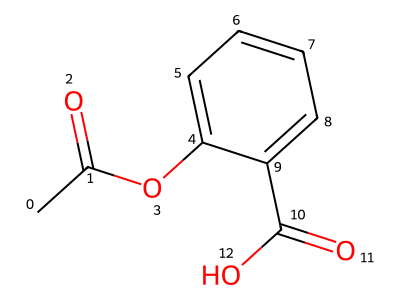

In [1]:
from rdkit import Chem
from rdkit.Chem import AllChem, Draw
from rdkit.Chem.Draw import IPythonConsole
import numpy as np

# Aspirin
smiles = "CC(=O)OC1=CC=CC=C1C(=O)O"
mol = Chem.MolFromSmiles(smiles)

# Generate fingerprint with bit info
fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=2, nBits=128)
fp_array = np.array(list(fp))

print("Aspirin fingerprint first 20 bits:")
print(fp_array[:20])
print(f"\nNumber of 1's in first 20 bits: {sum(fp_array[:20])}")
print(f"Number of 0's in first 20 bits: {20 - sum(fp_array[:20])}")

# Show which bits are 1
print("\nPositions with value 1 in first 20 bits:")
for i, val in enumerate(fp_array[:20]):
    if val == 1:
        print(f"  Bit {i} = 1")

# Draw the molecule with atom numbers
print("\nAspirin structure (atoms numbered):")
mol_with_numbers = Chem.Mol(mol)
for atom in mol_with_numbers.GetAtoms():
    atom.SetProp('atomNote', str(atom.GetIdx()))
Draw.MolToImage(mol_with_numbers, size=(400, 300))

Explanation Script Continues:
"Each '1' in positions 2, 5, 10, 11, and 13 means aspirin contains specific substructures centered around certain atoms. For example, bit 2 might represent a benzene ring pattern, bit 5 might represent the carboxylic acid group. The fingerprint is essentially a checklist: does this molecule contain substructure A? substructure B? etc. Machine learning uses this checklist to find patterns that correlate with drug activity."